## Model Training - Dicision Tree

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
 # Step 1: Import Libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import joblib

 #Step 2: Load Dataset

chi2_df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/chi2_pca_df.csv")  # Adjust path if needed
print(" CHI2+PCA Dataset Loaded!")
print("Shape:", chi2_df.shape)


 CHI2+PCA Dataset Loaded!
Shape: (27875, 10)


 Data Split Completed
Decision Tree Trained Successfully!

 Evaluation Results (CHI2+PCA):
Accuracy: 0.8298
Precision: 0.8478
Recall: 0.8632
F1 score: 0.8554

Confusion Matrix:
 [[1818  504]
 [ 445 2808]]


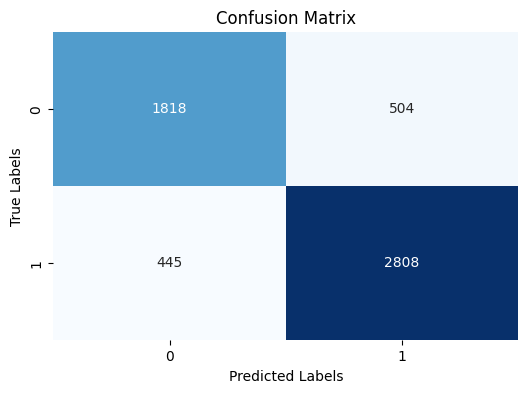


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79      2322
           1       0.85      0.86      0.86      3253

    accuracy                           0.83      5575
   macro avg       0.83      0.82      0.82      5575
weighted avg       0.83      0.83      0.83      5575



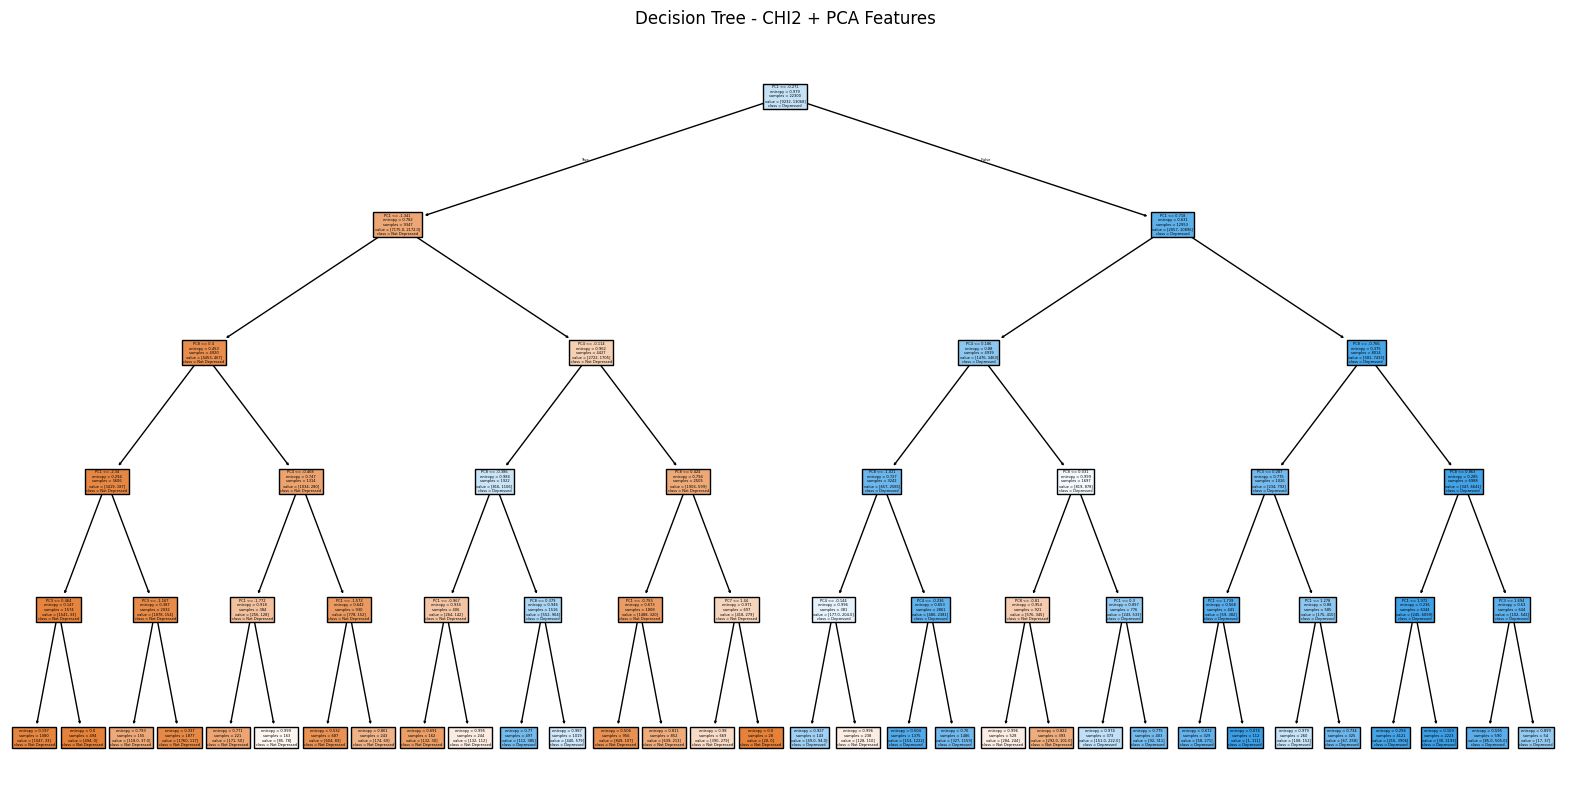

 Model Saved: decision_tree_chi2.pkl


In [40]:
 #Step 3: Prepare Data

target_col = "Depression"
X = chi2_df.drop(columns=[target_col])
y = chi2_df[target_col]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(" Data Split Completed")

#Step 4: Train Decision Tree

tree_chi2 = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
tree_chi2.fit(X_train, y_train)
print("Decision Tree Trained Successfully!")

# Step 5: Evaluate Model

y_pred = tree_chi2.predict(X_test)

print("\n Evaluation Results (CHI2+PCA):")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
from sklearn.metrics import precision_score, recall_score, f1_score # Import missing metrics
print("Precision:", round(precision_score(y_test, y_pred), 4))
print ("Recall:", round(recall_score(y_test, y_pred), 4)  )
print("F1 score:", round(f1_score(y_test, y_pred),4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have y_test and y_pred
cm = confusion_matrix(y_test, y_pred)

# Option 1: Using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))


 # Step 6: Visualize Tree

plt.figure(figsize=(20,10))
plot_tree(tree_chi2, filled=True, feature_names=X.columns, class_names=['Not Depressed','Depressed'])
plt.title("Decision Tree - CHI2 + PCA Features")
plt.show()

# Step 7: Save Model

joblib.dump(tree_chi2, "decision_tree_chi2.pkl")
print(" Model Saved: decision_tree_chi2.pkl")

In [32]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score # Import missing metrics


# Split data (if not already split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# GridSearchCV with 5-fold CV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)
print("\n Evaluation Results (CHI2+PCA):")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 score:", round(f1_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
# Predict on test set using best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Precision, Recall, F1-score
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV Accuracy: 0.8346188340807175

 Evaluation Results (CHI2+PCA):
Accuracy: 0.8317
F1 score: 0.8589
Precision: 0.8407
Recall: 0.878
Test Accuracy: 0.8317488789237668

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79      2322
           1       0.84      0.88      0.86      3253

    accuracy                           0.83      5575
   macro avg       0.83      0.82      0.83      5575
weighted avg       0.83      0.83      0.83      5575



In [43]:
# Step 1: Import Libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score # Import missing metrics


# Step 2: Load Dataset
rfe_df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/rfe_pca_df.csv")  # Adjust path if needed
print(" RFE+PCA Dataset Loaded!")
print("Shape:", rfe_df.shape)


 RFE+PCA Dataset Loaded!
Shape: (27875, 9)


 Data Split Completed
 Decision Tree Trained Successfully!

 Evaluation Results (RFE+PCA):
Accuracy: 0.8271
Precision: 0.8547
Recall: 0.8478
F1 score: 0.8512

Confusion Matrix:
 [[1853  469]
 [ 495 2758]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.79      2322
           1       0.85      0.85      0.85      3253

    accuracy                           0.83      5575
   macro avg       0.82      0.82      0.82      5575
weighted avg       0.83      0.83      0.83      5575



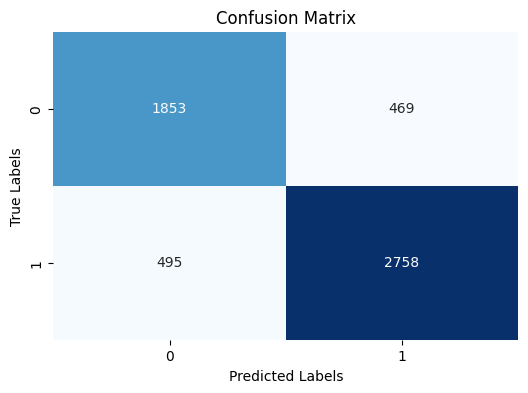

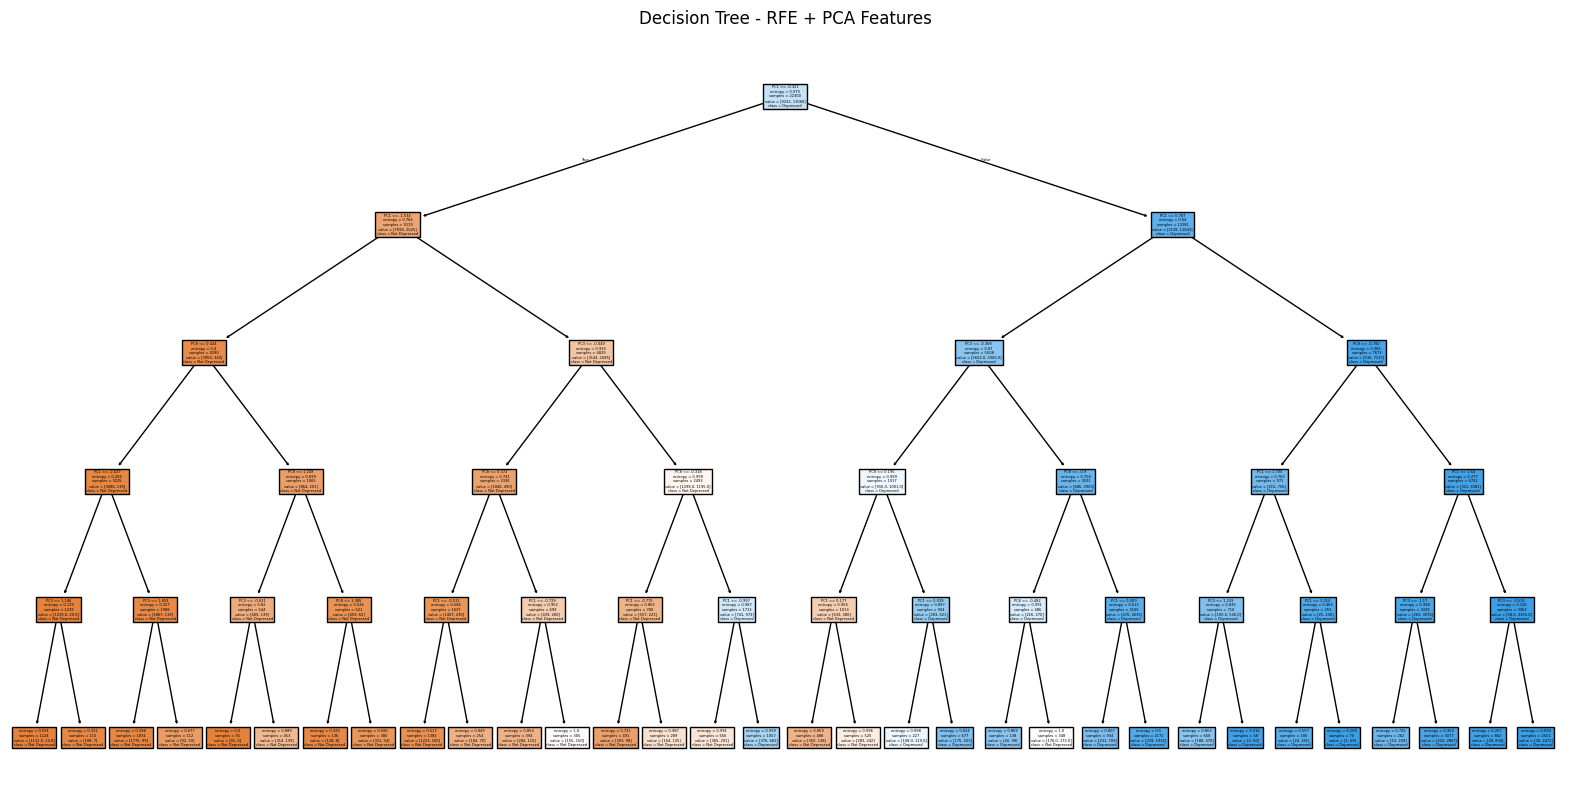

 Model Saved: decision_tree_rfe.pkl


In [44]:
# Step 3: Prepare Data
target_col = "Depression"
X = rfe_df.drop(columns=[target_col])
y = rfe_df[target_col]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(" Data Split Completed")

# Step 4: Train Decision Tree
tree_rfe = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
tree_rfe.fit(X_train, y_train)
print(" Decision Tree Trained Successfully!")

 #Step 5: Evaluate Model
y_pred = tree_rfe.predict(X_test)

print("\n Evaluation Results (RFE+PCA):")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 score:", round(f1_score(y_test, y_pred),4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


print("\nClassification Report:\n", classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have y_test and y_pred
cm = confusion_matrix(y_test, y_pred)

# Option 1: Using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

 #Step 6: Visualize Tree

plt.figure(figsize=(20,10))
plot_tree(tree_rfe, filled=True, feature_names=X.columns, class_names=['Not Depressed','Depressed'])
plt.title("Decision Tree - RFE + PCA Features")
plt.show()


# Step 7: Save Model

joblib.dump(tree_rfe, "decision_tree_rfe.pkl")
print(" Model Saved: decision_tree_rfe.pkl")


In [36]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split data (if not already split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# GridSearchCV with 5-fold CV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

print("\n Evaluation Results (RFE+PCA):")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 score:", round(f1_score(y_test, y_pred),4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



# Predict on test set using best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Precision, Recall, F1-score
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV Accuracy: 0.8346188340807175

 Evaluation Results (RFE+PCA):
Accuracy: 0.8317
Precision: 0.8407
Recall: 0.878
F1 score: 0.8589

Confusion Matrix:
 [[1781  541]
 [ 397 2856]]
Test Accuracy: 0.8317488789237668

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79      2322
           1       0.84      0.88      0.86      3253

    accuracy                           0.83      5575
   macro avg       0.83      0.82      0.83      5575
weighted avg       0.83      0.83      0.83      5575

